
## Research question
Can regional win percentage and seeding be used to predict where teams will finish in the March Madness tournament?

In [2]:
# libraries and reading in data
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)
data <- read_csv("https://raw.githubusercontent.com/diverse-data-hub/diversedata/refs/heads/main/data-clean/womensmarchmadness.csv")
head(data, 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

year,school,seed,conference,conf_wins,conf_losses,conf_wins_pct,conf_rank,division,reg_wins,reg_losses,reg_wins_pct,bid,first_game_at_home,tourney_wins,tourney_losses,tourney_finish,total_wins,total_losses,total_wins_pct
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1982,Arizona St.,4,Western Collegiate,NA,NA,NA,NA,NA,23,6,79.3,at-large,Y,1,1,top_16_loss,24,7,77.4
1982,Auburn,7,Southeastern,NA,NA,NA,NA,NA,24,4,85.7,at-large,N,0,1,first_round_loss,24,5,82.8
1982,Cheyney,2,Independent,NA,NA,NA,NA,NA,24,2,92.3,at-large,Y,4,1,top_2_loss,28,3,90.3
1982,Clemson,5,Atlantic Coast,6,3,66.7,4,NA,20,11,64.5,at-large,N,0,1,first_round_loss,20,12,62.5
1982,Drake,4,Missouri Valley,NA,NA,NA,NA,NA,26,6,81.3,auto,Y,2,1,top_8_loss,28,7,80.0
1982,East Carolina,6,Independent,NA,NA,NA,NA,NA,19,7,73.1,at-large,N,0,1,first_round_loss,19,8,70.4


In [3]:
# Selects seed, regional win percentage, and tournament finish from original data
selected_data <- select(data, seed, reg_wins_pct, tourney_finish)

# Removes small number of rows with "opening_round_loss" in tourney_finish column
selected_data <- filter(selected_data, tourney_finish != "opening_round_loss") |>
mutate(tourney_finish = as_factor(tourney_finish))

head(selected_data, 6)

seed,reg_wins_pct,tourney_finish
<dbl>,<dbl>,<fct>
4,79.3,top_16_loss
7,85.7,first_round_loss
2,92.3,top_2_loss
5,64.5,first_round_loss
4,81.3,top_8_loss
6,73.1,first_round_loss


---

In [ ]:
# aggregate statistics for regional win percentage
only_numeric <- select(selected_data, reg_wins_pct) 

summary_table <- only_numeric |>
summarize(mean_wins_pct = mean(reg_wins_pct, na.rm = TRUE), 
          max_wins_pct = max(reg_wins_pct, na.rm = TRUE), 
          min_wins_pct = min(reg_wins_pct, na.rm = TRUE))

summary_table

In [5]:
# check na values
na_table <- selected_data |>
summarize(across(everything(), is.na)) |>
summarize(across(everything(), sum)) |>
pivot_longer(seed:tourney_finish,
             names_to = "column",
             values_to = "amount of na observations")

na_table

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


column,amount of na observations
<chr>,<int>
seed,0
reg_wins_pct,0
tourney_finish,0


In [6]:
# average win percentage for every tournament finish place
mean_win_pct_per_finish <- selected_data |>
group_by(tourney_finish) |>
summarize(mean_win_pct = mean(reg_wins_pct, na.rm = TRUE))

mean_win_pct_per_finish

tourney_finish,mean_win_pct
<fct>,<dbl>
top_16_loss,79.44696
first_round_loss,72.54788
top_2_loss,87.98919
⋮,⋮
champ,91.73784
top_4_loss,87.28919
second_round_loss,74.97996


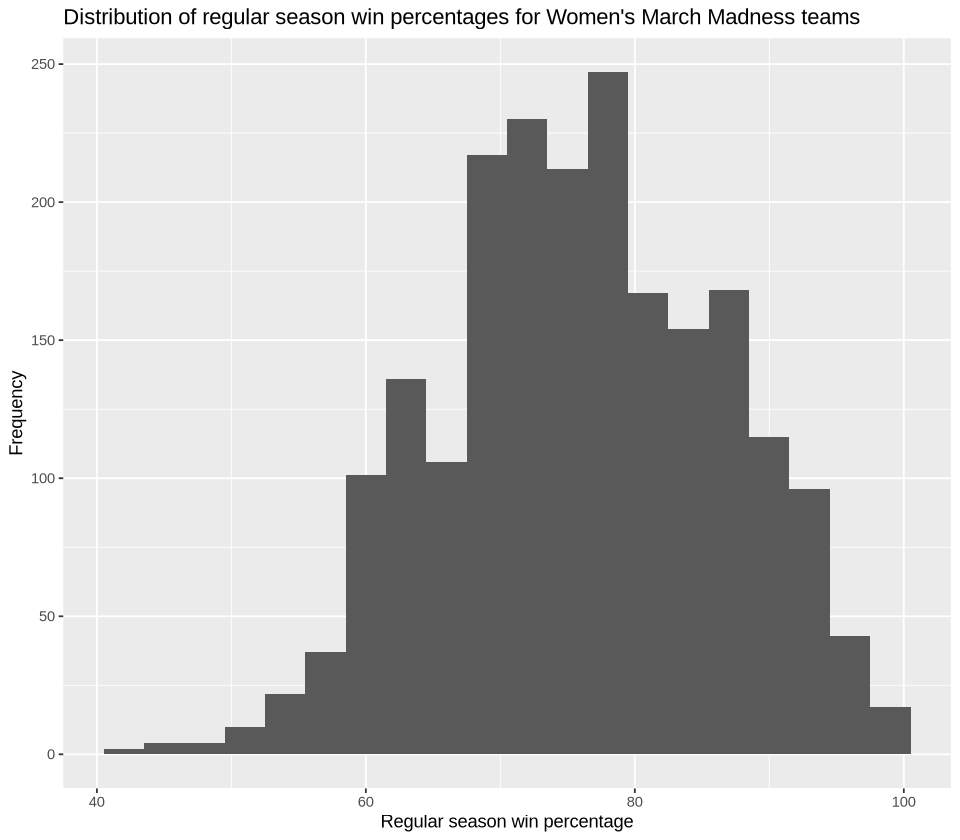

In [7]:
options(repr.plot.width = 8, repr.plot.height = 7)
reg_win_pct_plot <- ggplot(selected_data, aes(x = reg_wins_pct)) +
geom_histogram(binwidth = 3) +
labs(title = "Distribution of regular season win percentages for Women's March Madness teams",
    x = "Regular season win percentage",
    y = "Frequency")

reg_win_pct_plot

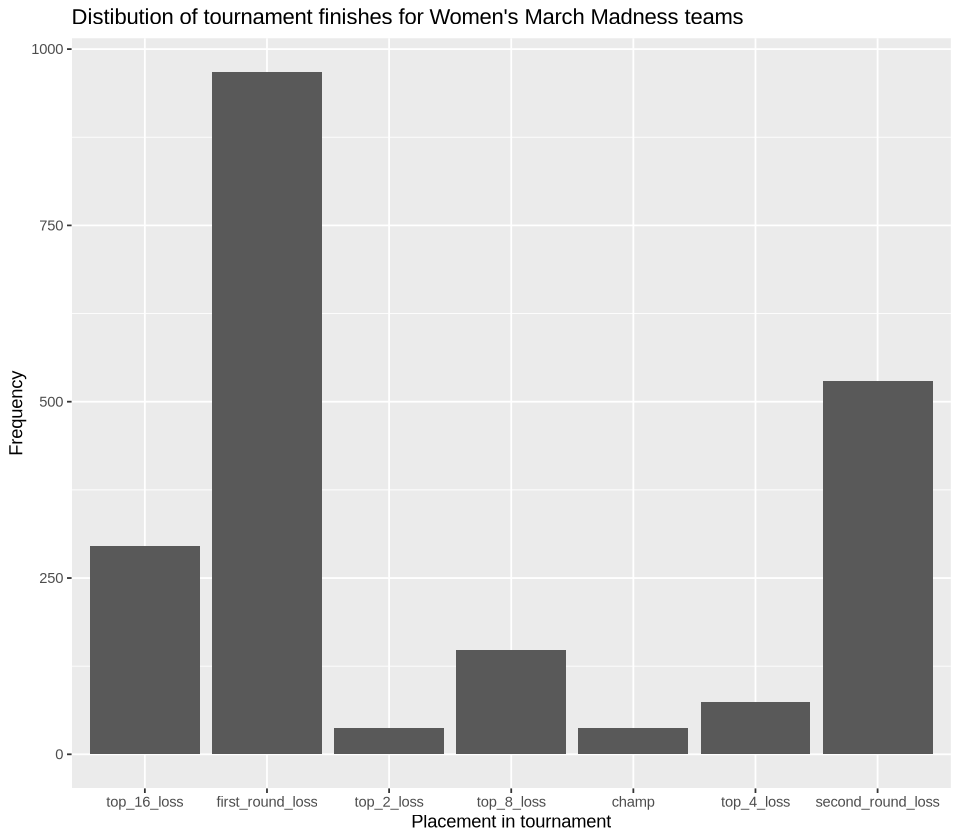

In [8]:
options(repr.plot.width = 8, repr.plot.height = 7)
tourney_finish_plot <- ggplot(selected_data, aes(x = tourney_finish)) +
geom_bar() +
labs(title = "Distibution of tournament finishes for Women's March Madness teams",
    x = "Placement in tournament", 
    y = "Frequency")
tourney_finish_plot

The first visualization is relevant to the research question because it looks at how one of the predictors, seeding of teams in the tournament, is related to where teams actually place in the tournament. This visualization is important to the analysis because it allows us to see that seeding is a reasonably strong predictor for actual tournament performance, with only 1st-3rd seeds ever winning the tournament. Therefore, we would expect a positive correlation in seeding and actual placement when answering the research question.

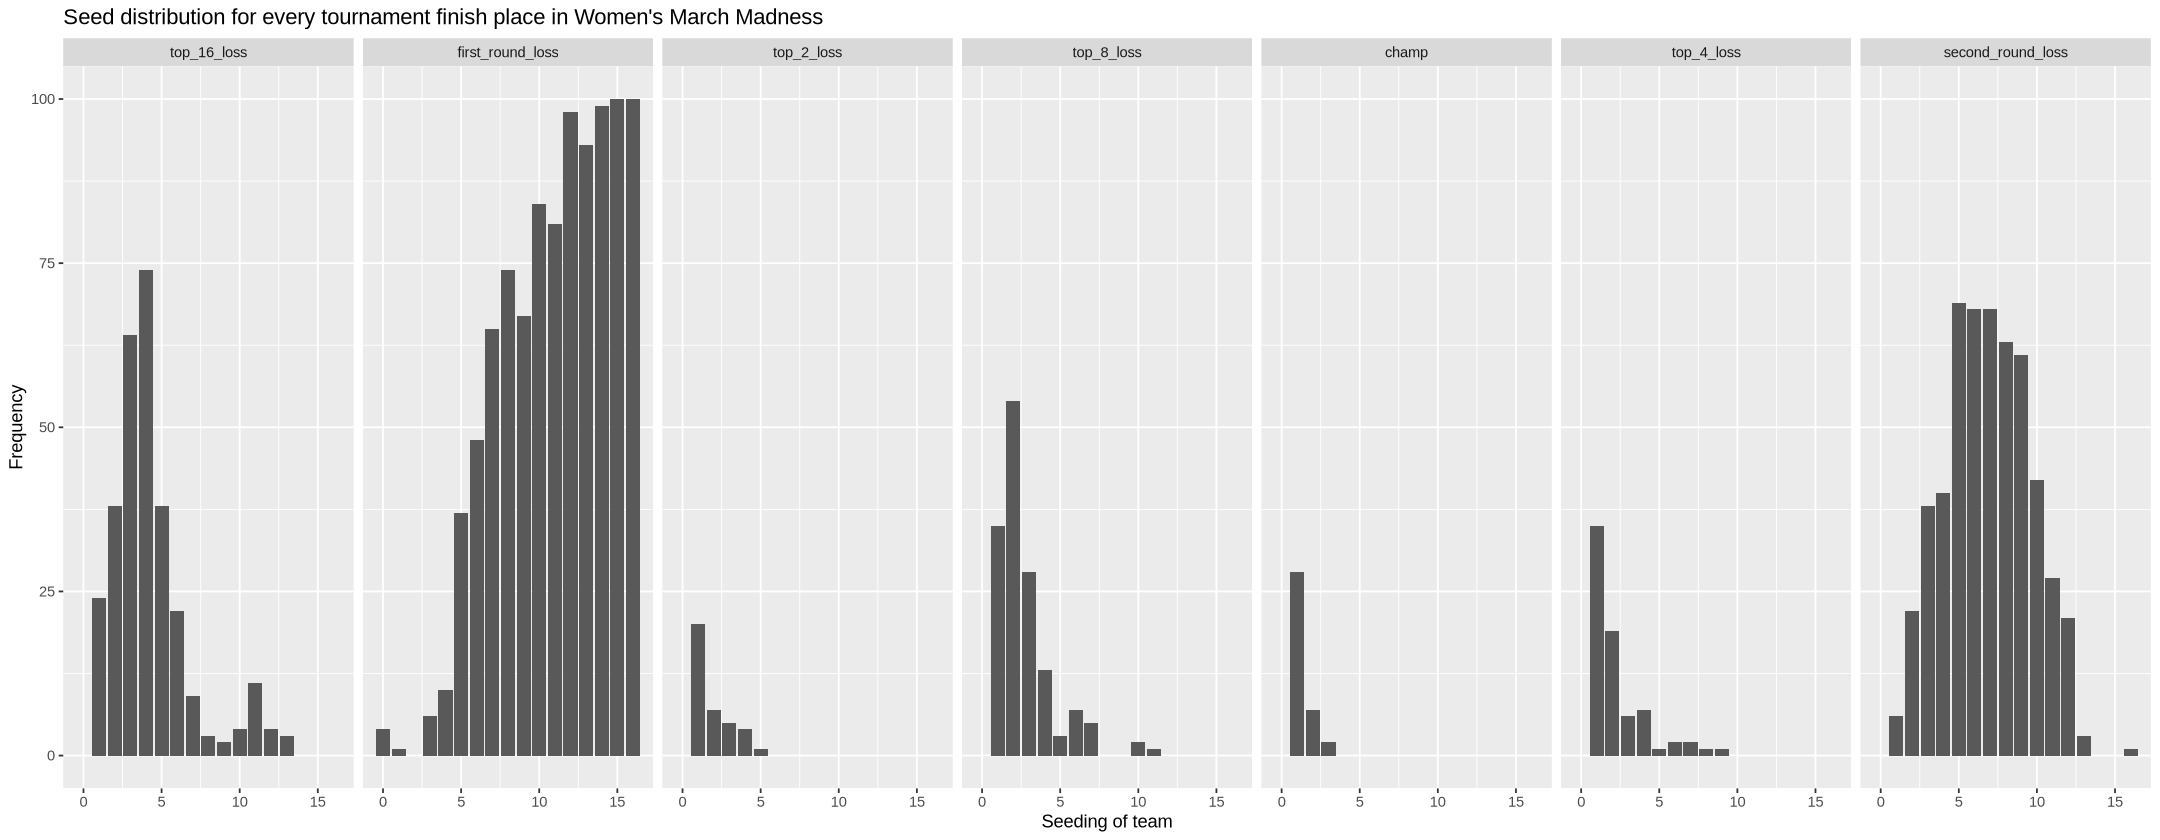

In [9]:
options(repr.plot.width = 18, repr.plot.height = 7)
seed_finish_plot <- ggplot(selected_data, aes(x = seed)) +
geom_bar() +
facet_grid(cols = vars(tourney_finish)) +
labs(title = "Seed distribution for every tournament finish place in Women's March Madness",
     x = "Seeding of team", y = "Frequency")
seed_finish_plot

This second visualization is important to answer the research question because it looks at the other predictor, which is regional win percentage, and its relationship with how teams place in the March Madness tournament. We see that there is a strong positive correlation between the regional win percentages of teams and their performance in the March Madness tournament. Teams that got eliminated first had an average of below 75% for regional win percentage, while champions had an average of over 90%.

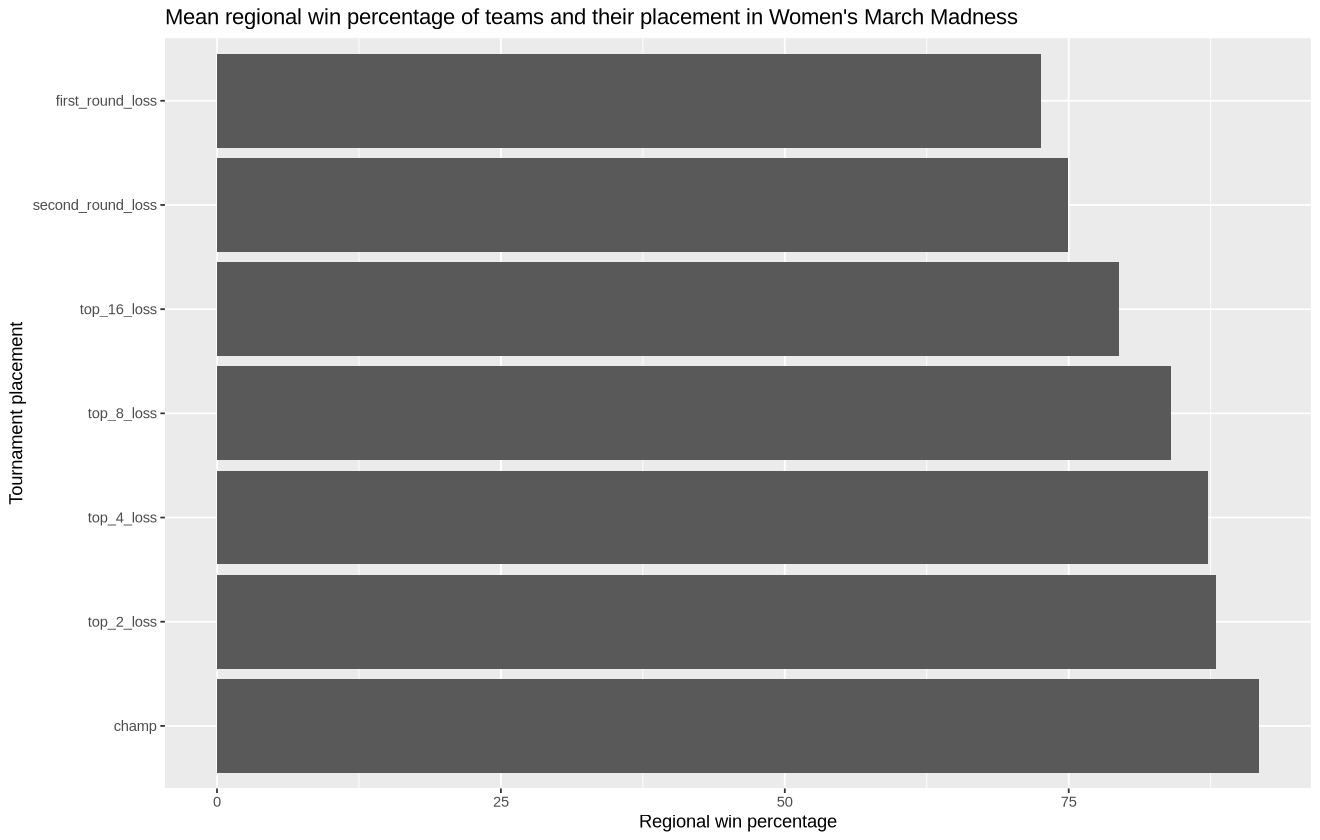

In [10]:
options(repr.plot.width = 11, repr.plot.height = 7)

mean_win_pct_per_finish <- selected_data |>
group_by(tourney_finish) |>
summarize(mean_win_pct = mean(reg_wins_pct, na.rm = TRUE)) |>
arrange()
mean_win_pct_per_finish_plot <- ggplot(mean_win_pct_per_finish, aes(x = mean_win_pct, y = fct_reorder(tourney_finish, mean_win_pct, .desc = TRUE))) +
geom_bar(stat = "identity") +
labs(title = "Mean regional win percentage of teams and their placement in Women's March Madness",
     x = "Regional win percentage", y = "Tournament placement")
mean_win_pct_per_finish_plot

------


## Analysis
- knn classification method used to determine the tournament standing of teams given their regional win percentage and their seeding
- predictors can be standardized by treating seeding as a numeric variable 
- 75% training : 25% testing split to create a validation set, cross-validation performed with 5 folds.
- k will be chosen from 1 to 50, based on which one generates gives the highest mean accuracy
- accuracy will be the main metric used to evaluate performance, as there are much more than two classes that we are predicting for. 

In [11]:
# Splitting the data into 75% training and 25% testing
split <- initial_split(selected_data, prop = 0.75, strata = tourney_finish)
training_data <- training(split)
testing_data <- testing(split)

# Creating initial model to tune our K value
spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
set_engine("kknn") |>
set_mode("classification")

# Creating recipe and standardizing predictors
recipe <- recipe(tourney_finish ~ seed + reg_wins_pct, data = selected_data) |>
step_scale(all_predictors()) |>
step_center(all_predictors())

# Creating ten folds for cross-validation
folds <- vfold_cv(training_data, v = 5, strata = tourney_finish)

# Testing best value of K from 1 to 50
k_vals <- tibble(neighbors = seq(from = 1, to = 50, by = 1))

# Obtaining the table with values of K and corresponding mean accuracies
knn_results <- workflow() |>
add_recipe(recipe) |>
add_model(spec) |>
tune_grid(resamples = folds, grid = k_vals) |>
collect_metrics() |>
filter(.metric == "accuracy")

# Obtaining row with highest mean and corresponding K
highest <- knn_results |>
group_by(.metric) |>
slice_max(order_by = mean, n = 1)

highest

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
31,accuracy,multiclass,0.5814887,5,0.007182134,Preprocessor1_Model31


In [14]:
# From highest we determine that mean accuracy is highest when K = 31, at ~0.6, so we use that value for our model
spec_tuned <- nearest_neighbor(weight_func = "rectangular", neighbors = 31) |>
set_engine("kknn") |>
set_mode("classification")

# Fitting model with training data
data_fit <- workflow() |>
add_recipe(recipe) |>
add_model(spec_tuned) |>
fit(data = training_data)

# Making predictions for tournament finish on testing data
predictions <- predict(data_fit, testing_data) |>
bind_cols(testing_data)
predictions

# Obtaining accuracy
metrics <- predictions |>
metrics(truth = tourney_finish, estimate = .pred_class)
metrics

# Obtaining confusion matrix
conf_mat <- predictions |>
conf_mat(truth = tourney_finish, estimate = .pred_class)
conf_mat

.pred_class,seed,reg_wins_pct,tourney_finish
<fct>,<dbl>,<dbl>,<fct>
top_8_loss,2,92.3,top_2_loss
first_round_loss,7,72.4,first_round_loss
top_16_loss,3,86.2,top_16_loss
⋮,⋮,⋮,⋮
first_round_loss,8,73.3,first_round_loss
top_8_loss,2,81.3,top_16_loss
top_16_loss,4,72.7,top_16_loss


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,multiclass,0.5812620
kap,multiclass,0.3896601


                   Truth
Prediction          top_16_loss first_round_loss top_2_loss top_8_loss champ
  top_16_loss                37                7          3         12     1
  first_round_loss            5              190          0          2     0
  top_2_loss                  0                0          0          0     0
  top_8_loss                 12                1          5         19     7
  champ                       0                0          0          0     3
  top_4_loss                  2                0          1          1     1
  second_round_loss          17               47          0          3     0
                   Truth
Prediction          top_4_loss second_round_loss
  top_16_loss                7                19
  first_round_loss           1                53
  top_2_loss                 0                 0
  top_8_loss                 7                 2
  champ                      1                 0
  top_4_loss                 0          

The visualization shows what predictions the model made when compared to every actual tournament finish place. Using a facet grid, with each individual bar graph representing model predictions for a specific tournament finish, the bar graph shows how accurate the model is for predicting every tournament finish. The visualization is important to the analysis because it shows the differences in the accuracy of the model depending on what the actual tournament finish of an observation is. 

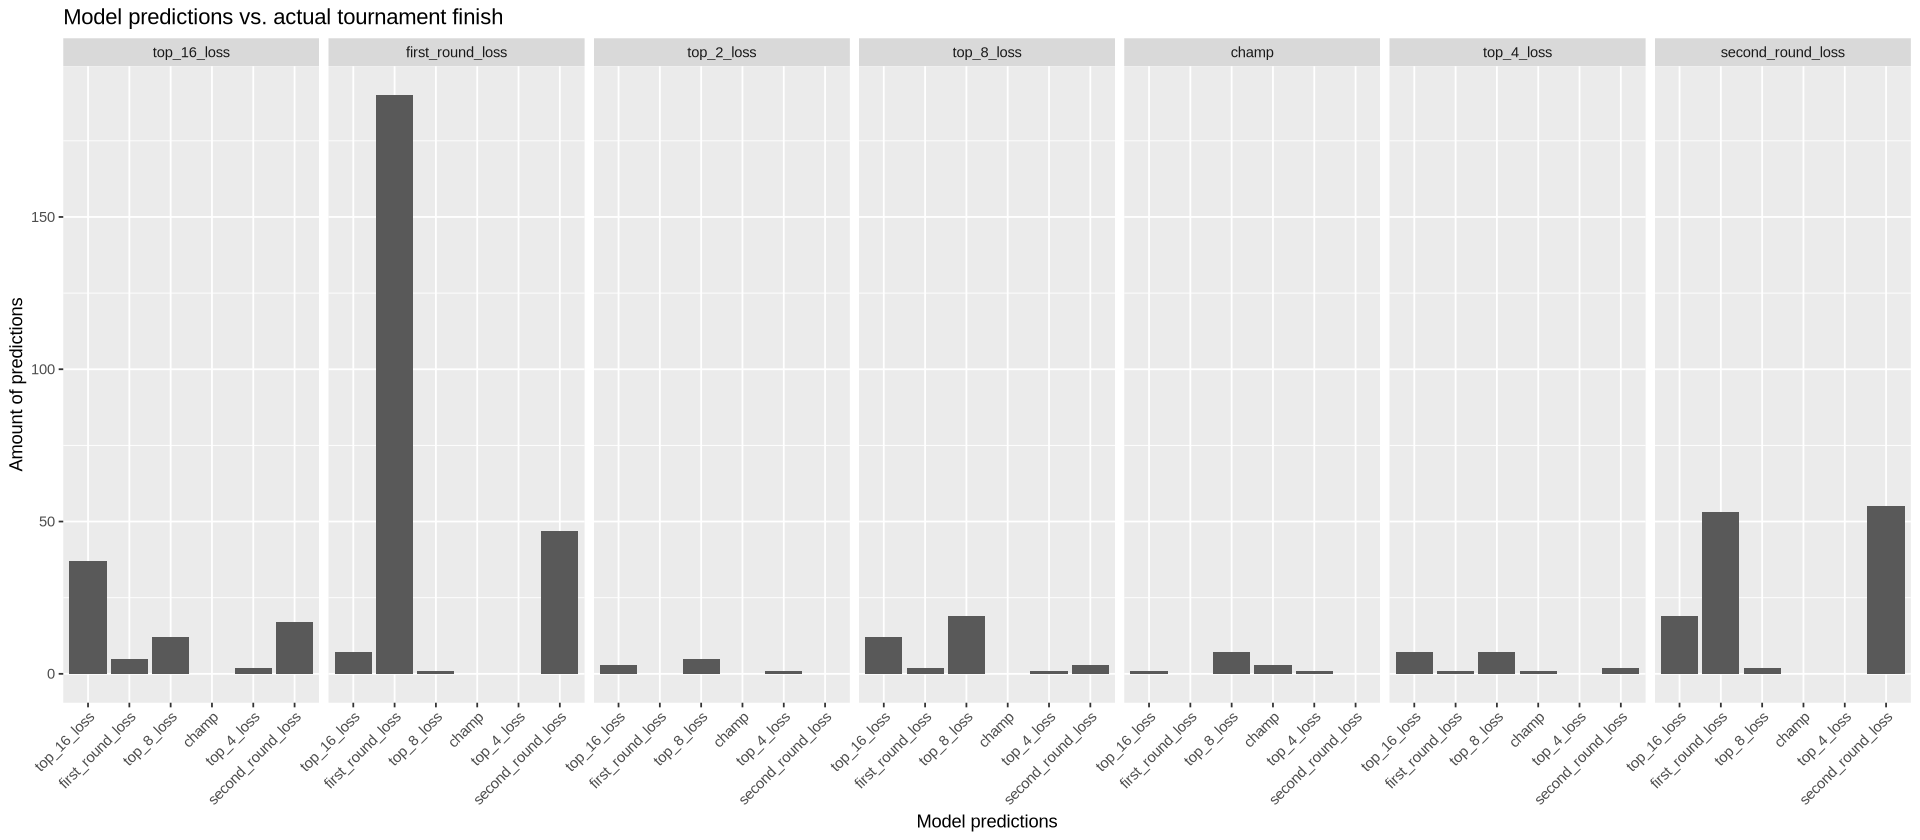

In [15]:
options(repr.plot.width = 16, repr.plot.height = 7)
tourney_finish_plot <- ggplot(predictions, aes(x = .pred_class)) +
geom_bar() +
facet_grid(cols = vars(tourney_finish)) +
labs(title = "Model predictions vs. actual tournament finish",
     x = "Model predictions", y = "Amount of predictions") +
# Adding tilt to bar labels for readability
theme(axis.text.x = element_text(angle = 45, hjust = 1))
tourney_finish_plot

-----

## Discussion

In summary, seeding and regional win percentage were not particularily effective predictors for tournament placement in general. While these predictors were highly accurate for predicting first round losses with the given predictors as seen in the plot above, for higher placements in the tournament the model predicted with less than 50% accuracy. Furthermore, it appears that this accuracy decreases with higher tournament placements, with the correct champion being predicted only once. This could be because of the exponentially decreasing amount of data points for higher placements, meaning that there is less likely to be a large amount of neighbors and therefore biasing the model towards lower predictions. 

One adjustment I had to make was the range of k values that I tuned for. Initially, I planned on tuning for the range 1-10, but I noticed that the mean accuracy was increasing linearly with K, implying that I needed a wider range to find the best K value. Therefore, I opted to find k over the range 1-50 instead.

The results of the analysis were about as expected, as there are a massive variety of factors that cannot be measured that goes into the performance of a team at a tournament, especially a single elimination tournament like March Madness. Therefore, it is difficult to accurately predict tournament performance using only factors like win percentage. However, I was suprised at the amount of dropoff of the accuracy of the model between first round losses and second round losses.

The results indicate that more predictors or more data would be necessary to develop a more accurate model that can be used for purposes such as sports betting. Future questions could include how adding more predictors, such as team historical performances or player quality, could improve the accuracy of the model. Furthermore, questions could be asked about the feasibility of using seeding as a predictors, given its categorical nature.



## References:
https://dplyr.tidyverse.org/reference/index.html